# COE311K Final Project Part 3
Clay Watson (cw43456)
Aamil Dholasania (amd7297)
Eric Denis (ejd2322)

# Section 1: Review of Part 2

In part 2, an ordinary differential equation arising from Newton's Law of Cooling with a time-varying ambient temperature was solved using an implicit method. The governing equation was dT/dt = -1000T + 1000(300 + 50sin(0.01t)) with an initial condition of T(0) = 500 K.

The system exhibits stiffness due to widely separated time scales, with the fast time scale being 0.001 seconds and the slow time scale being 100 seconds. This results in a stiffness ratio of approximately 10^5, which indicates a highly stiff system.

Numerical challenges arise in part 2 of the project since Forward Euler's method is required with an h value of less than 0.002 for stability. This leads to extremely large step counts (approximately 50,000 for long simulations), making explicit methods impractical for our use.

For the Implicit Solver section of part 2, Backwards Euler method was implemented: T_{n+1} = T_n + h f(t_{n+1}, T_{n+1}). The Newton-Raphson method was used to solve the nonlinear equation at each step. A few observations from this section include the finding that Backward Euler's method is unconditionally stable, Newton-Raphson converges after 1 or 2 iterations, and the fact that many fewer steps are required compared to Forward Euler's method.

While Backward Euler's method improves stability, challenges still remain in the fact that Newton-Raphson can fail for poor initial guesses, and fixed step size is inefficient across varying regions of the overall solution. In part 3 of this project, we will address these issues using Newton-Raphson damping and adaptive step size control to prove the methods effective.

# Section 2: Newton-Raphson Damping

The Newton-Raphson iteration can fail (or diverge) when initial guesses are poor, step sizes are large, and there is not a strong linear relationship in the solution. To improve the strength, a damping factor, alpha, is introduced. The equation for this damping factor is y^(k+1) = y^(k) - alpha * g(y^(k)) / g'(y^(k)) where alpha is greater than 0 but less than or equal to 1. 

To assist the line search strategy, instead of taking alpha = 1, we are going to (1) try a full Newton step, (2) reduce alpha if the residual does not decrease, and (3) repeat until it has improved. We will troubleshoot to ensure stability and prevent divergence. 

We are implementing damping and line searching in order to prevent overshooting, improve convergence reliability, and allow larger time steps to safely run. 

In [1]:
# Section 2 Code
import numpy as np
import matplotlib.pyplot as plt 

# Residual function for Backward Euler
def g(T_guess, T_n, t_next, h):
    return T_guess - T_n - h * (-1000*T_guess + 1000*(300 + 50*np.sin(0.01*t_next)))

# Constant derivative
def g_prime(h):
    return 1 + 1000*h


# Process for Damped Newton Raphson using line search
def damped_newton_raphson(T_n, t_next, h, tol=1e-6, max_iter=20):
    T_guess = T_n
    
    for k in range(max_iter):
        g_val = g(T_guess, T_n, t_next, h)
        
        if abs(g_val) < tol:
            return T_guess, k, True
        
        gp = g_prime(h)
        delta = -g_val / gp
        
        alpha = 1.0
        g_current = abs(g_val)
        
        # Line search (backtracking)
        for _ in range(10):
            T_new = T_guess + alpha * delta
            g_new = abs(g(T_new, T_n, t_next, h))
            
            if g_new < g_current:
                break
            
            alpha *= 0.5
        
        # Track if damping was used
        damped = alpha < 1.0
        
        T_guess = T_new
    
    return T_guess, max_iter, False

# Section 3: Adaptive Step Size

Using a fixed step size is inefficient because the solution changes rapidly at early times, and the solution also changes slowly afterward. To combat this, we construct an adaptive step size using a step-doubling approach. We will estimate the error by comparing one step of size h with two steps of size h/2. The error estimate is given by the following equation: error = abs(y_(h/2) - y_h).

To adjust the step size, the new step sizes are computed as h_new = h * sqrt(tol/err). Safeguards are in place to ensure that the solution runs smoothly, which include a safety factor, minimum/maximum step size, and limits on step growth and shrinkage.

To ensure that the output yields a valid solution, the code includes an accept or reject system. If the error is less than the tolerance, the step is accepted. If the case is anything else but that, the step is rejected and retried with a smaller h-value. The main idea here is that we want to use the more accurate solution, which would be two half steps, when accepting the step.

In [2]:
# Backward Euler's method for one step using damped Newton
def implicit_step(T_n, t_n, h):
    t_next = t_n + h
    T_next, iters, success = damped_newton_raphson(T_n, t_next, h)
    return T_next, iters, success


# Error Estimate for Step-Doubling approach
def estimate_error(T_n, t_n, h):
    # One full step
    T_full, it1, _ = implicit_step(T_n, t_n, h)
    
    # Two half steps
    T_half1, it2, _ = implicit_step(T_n, t_n, h/2)
    T_half2, it3, _ = implicit_step(T_half1, t_n + h/2, h/2)
    
    err = abs(T_half2 - T_full)
    total_iters = it1 + it2 + it3
    
    return T_full, T_half2, err, total_iters

# Adaptive step size Implicit solver
def adaptive_solver(T0, t0, tf, h0, tol=1e-4):
    t_vals = [t0]
    T_vals = [T0]
    h_vals = []
    error_vals = []
    
    t = t0
    T = T0
    h = h0
    
    accepted = 0
    rejected = 0
    total_iters = 0
    
    while t < tf:
        if t + h > tf:
            h = tf - t
        
        T_full, T_half, err, iters = estimate_error(T, t, h)
        total_iters += iters
        
        if err < tol:
            # Accept
            t += h
            T = T_half
            
            t_vals.append(t)
            T_vals.append(T)
            h_vals.append(h)
            error_vals.append(err)
            
            accepted += 1
            
            # Increase step size
            if err > 1e-12:
                h = 0.9 * h * np.sqrt(tol / err)
            else:
                h *= 2
        else:
            # Reject
            h = 0.9 * h * np.sqrt(tol / err)
            rejected += 1
    
    stats = {
        "accepted": accepted,
        "rejected": rejected,
        "total_iters": total_iters
    }
    
    return np.array(t_vals), np.array(T_vals), h_vals, error_vals, stats

# Section 4: Performance Analysis

This section compares the fixed-step Backward Euler's method solver from part 2 with the adaptive step size implicit solver in part 3. The purpose of this comparison is to evaluate whether adaptive step sizing improves efficiency while maintaining accuracy. The fixed-step method uses a constant step size for the entire simulation, while the adaptive method automatically changes the step size based on an estimate of the error. There are 2 comparisons being made: same target accuracy, which compares total steps and Newton-Raphson iterations, and same step budget, which compares final accuracy using a similar number of steps. We expect that the adaptive method will have an advantage because it should take small steps during the fast initial transient and larger steps once the solution becomes smoother.

Performance Comparison
----------------------
Fixed-step Backward Euler steps: 200
Adaptive solver accepted steps: 1575
Fixed-step Newton iterations: 200.0
Adaptive solver Newton iterations: 4734
Fixed-step maximum error: 18.121717754033682
Adaptive maximum error: 16.777927877612512
Adaptive rejected steps: 3


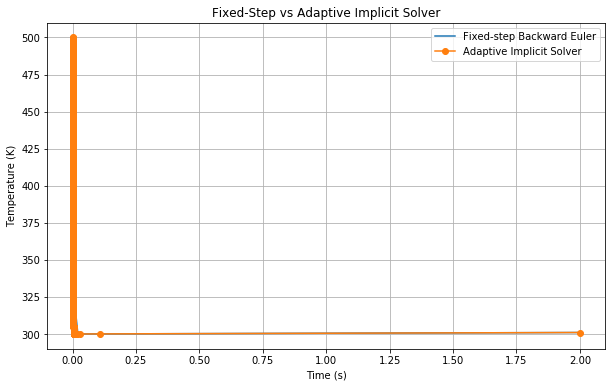

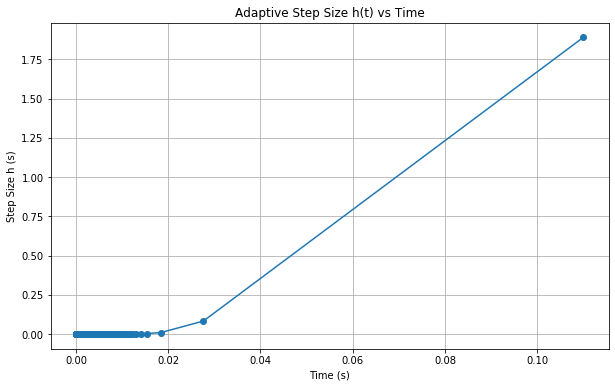

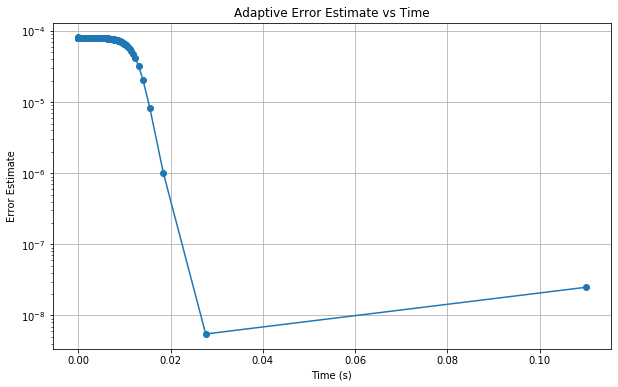

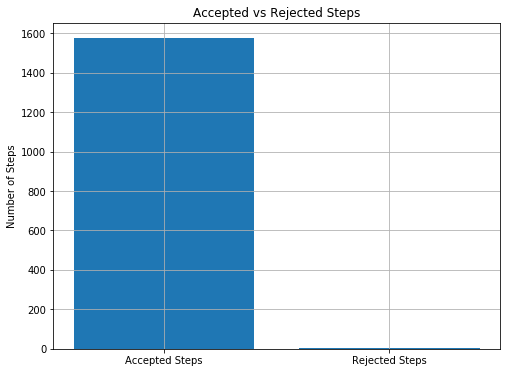

In [3]:
# Fixed-step Backward Euler solver using damped Newton-Raphson
def backward_euler_fixed(T0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    T_values = np.zeros(len(t_values))
    iteration_counts = np.zeros(len(t_values) - 1)

    # Initial condition
    T_values[0] = T0

    # Time stepping loop
    for i in range(1, len(t_values)):
        T_n = T_values[i - 1]
        t_next = t_values[i]

        # Solve implicit step using damped Newton-Raphson
        T_next, num_iters, success = damped_newton_raphson(T_n, t_next, h)

        T_values[i] = T_next
        iteration_counts[i - 1] = num_iters

    return t_values, T_values, iteration_counts

# Reference solution using a small fixed step size
h_ref = 0.0005
t_ref, T_ref, _ = backward_euler_fixed(500, 0, 2, h_ref)

# Helper function to compute max error
def max_error(t_values, T_values, t_ref, T_ref):
    T_ref_interp = np.interp(t_values, t_ref, T_ref)
    error = np.abs(T_values - T_ref_interp)
    return np.max(error), error

# Fixed-step comparison
h_fixed = 0.01
t_fixed, T_fixed, iters_fixed = backward_euler_fixed(500, 0, 2, h_fixed)

# Adaptive solver comparison
t_adapt, T_adapt, h_hist, err_hist, stats_adapt = adaptive_solver(
    T0=500,
    t0=0,
    tf=2,
    h0=0.1,
    tol=1e-4
)

# Compute errors
fixed_max_err, fixed_err_time = max_error(t_fixed, T_fixed, t_ref, T_ref)
adapt_max_err, adapt_err_time = max_error(t_adapt, T_adapt, t_ref, T_ref)

# Performance metrics
fixed_steps = len(t_fixed) - 1
adapt_steps = stats_adapt["accepted"]

fixed_iters = np.sum(iters_fixed)
adapt_iters = stats_adapt["total_iters"]

print("Performance Comparison")
print("----------------------")
print(f"Fixed-step Backward Euler steps: {fixed_steps}")
print(f"Adaptive solver accepted steps: {adapt_steps}")
print(f"Fixed-step Newton iterations: {fixed_iters}")
print(f"Adaptive solver Newton iterations: {adapt_iters}")
print(f"Fixed-step maximum error: {fixed_max_err}")
print(f"Adaptive maximum error: {adapt_max_err}")
print(f"Adaptive rejected steps: {stats_adapt['rejected']}")

# Plot solution comparison with adaptive time points marked
plt.figure(figsize=(10,6))
plt.plot(t_fixed, T_fixed, label="Fixed-step Backward Euler")
plt.plot(t_adapt, T_adapt, 'o-', label="Adaptive Implicit Solver")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Fixed-Step vs Adaptive Implicit Solver")
plt.legend()
plt.grid(True)
plt.show()

# Plot step size vs. time
plt.figure(figsize=(10,6))
plt.plot(t_adapt[:-1], h_hist, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Step Size h (s)")
plt.title("Adaptive Step Size h(t) vs Time")
plt.grid(True)
plt.show()

# Plot error estimate vs. time
plt.figure(figsize=(10,6))
plt.semilogy(t_adapt[:-1], err_hist, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Error Estimate")
plt.title("Adaptive Error Estimate vs Time")
plt.grid(True)
plt.show()

# Plot Accepted vs rejected steps
plt.figure(figsize=(8,6))
plt.bar(["Accepted Steps", "Rejected Steps"],
        [stats_adapt["accepted"], stats_adapt["rejected"]])
plt.ylabel("Number of Steps")
plt.title("Accepted vs Rejected Steps")
plt.grid(True)
plt.show()

Performance Discussion

The adaptive step size solver automatically adjusts the step size based on the estimated error. At early times in the comparison, the solution rapidly changes because the temperature quickly approaches the ambient temperature. During this time region, the adaptive step size method reduces the step size to maintain accuracy.  

After the quick transient decays, the solution becomes smoother. The adaptive step size solver then increases the step size, reducing the total number of steps needed in the comparison. 

In the end, compared to the fixed-step method, the adaptive step method provides better control over the accuracy and efficiency tradeoff. It avoids wasting small steps in smooth regions while still protecting the solution from larger estimated errors during the rapidly changing time regions. 

# Section 5: Robustness Testing

This section tests whether the adaptive step size implicit solver remains reliable under difficult conditions. Two robustness, or strength, tests are performed. The first being with a very large initial step size (h_0 = 1.0) and the second being with a very tight tolerance (text{tol} = 10^{-8}). A robust adaptive step solver should not fail when the initial step size is too large. Instead, it should reject inaccurate steps, reduce the step size, and then continue on. Additionally, when the tolerance is very tight, the solver should automatically use smaller steps to satisfy the stricter error requirement.

Robustness Test 1: Large Initial Step Size
-----------------------------------------
Accepted steps: 1575
Rejected steps: 3
Total Newton iterations: 4734
Final temperature: 300.9994333951408


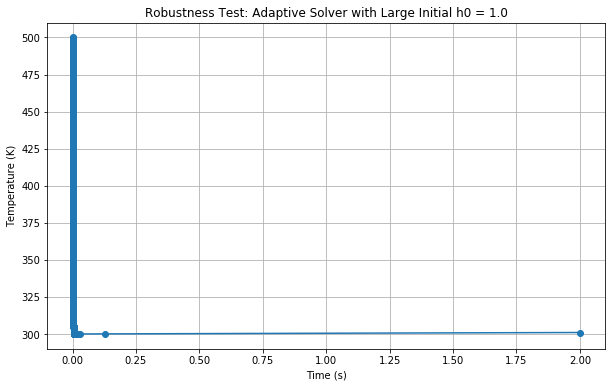

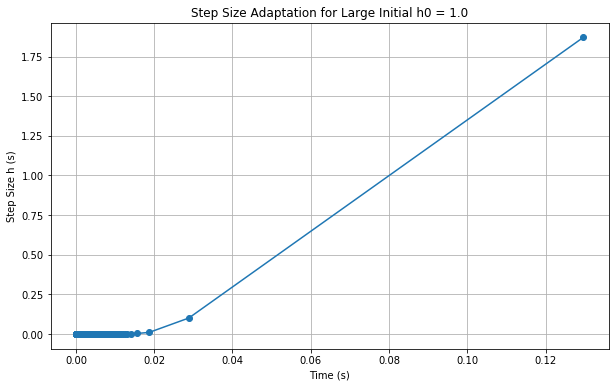

Robustness Test 2: Tight Tolerance
----------------------------------
Accepted steps: 157603
Rejected steps: 183
Total Newton iterations: 471010
Final temperature: 300.99943343123664


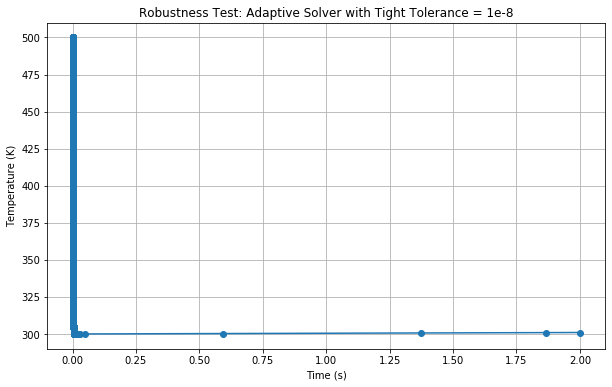

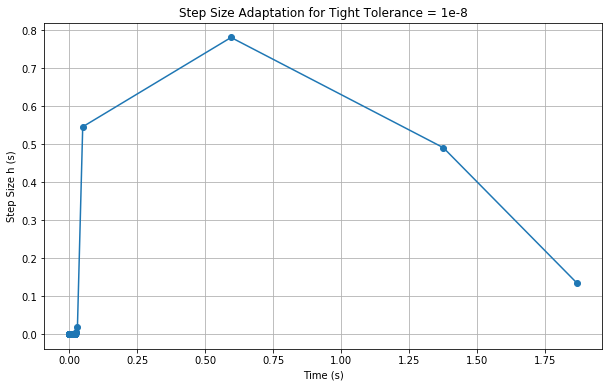

In [4]:
# Test 1: Very large initial step size
t_large_h, T_large_h, h_large_h, err_large_h, stats_large_h = adaptive_solver(
    T0=500,
    t0=0,
    tf=2,
    h0=1.0,
    tol=1e-4
)

print("Robustness Test 1: Large Initial Step Size")
print("-----------------------------------------")
print(f"Accepted steps: {stats_large_h['accepted']}")
print(f"Rejected steps: {stats_large_h['rejected']}")
print(f"Total Newton iterations: {stats_large_h['total_iters']}")
print(f"Final temperature: {T_large_h[-1]}")

# Plot large initial step size
plt.figure(figsize=(10,6))
plt.plot(t_large_h, T_large_h, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Robustness Test: Adaptive Solver with Large Initial h0 = 1.0")
plt.grid(True)
plt.show()

# Plot step size history for large initial h
plt.figure(figsize=(10,6))
plt.plot(t_large_h[:-1], h_large_h, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Step Size h (s)")
plt.title("Step Size Adaptation for Large Initial h0 = 1.0")
plt.grid(True)
plt.show()

# Test 2: Very tight tolerance
t_tight, T_tight, h_tight, err_tight, stats_tight = adaptive_solver(
    T0=500,
    t0=0,
    tf=2,
    h0=0.1,
    tol=1e-8
)

print("Robustness Test 2: Tight Tolerance")
print("----------------------------------")
print(f"Accepted steps: {stats_tight['accepted']}")
print(f"Rejected steps: {stats_tight['rejected']}")
print(f"Total Newton iterations: {stats_tight['total_iters']}")
print(f"Final temperature: {T_tight[-1]}")

# Plot solution for tight tolerance
plt.figure(figsize=(10,6))
plt.plot(t_tight, T_tight, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Robustness Test: Adaptive Solver with Tight Tolerance = 1e-8")
plt.grid(True)
plt.show()

# Plot step size history for tight tolerance
plt.figure(figsize=(10,6))
plt.plot(t_tight[:-1], h_tight, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Step Size h (s)")
plt.title("Step Size Adaptation for Tight Tolerance = 1e-8")
plt.grid(True)
plt.show()

Robustness Results

For the initial step size test, the solver begins with h = 1.0, which is much larger than the stable Forward Euler's method step size from part 2. The adaptive step size method handles this by estimating the error and reducing the step size when necessary. This shows that the method is robust, and unlikely to fail, compared to poor initial step size choices.

For the tight tolerance test, the solver uses smaller steps to satisfy the stricter error requirement. This increases the number of accepted steps and Newton-Raphson iterations, but the solution remains stable and accurate.

These tests show that the adaptive step size implicit solver is reliable under both difficult step size conditions and strong accuracy requirements.

# Section 6: Conclusions

This project took the implicit Backward Euler's method solver from Part 2 and extended its implications by adding Newton-Raphson damping and adaptive step size control. 

Newton-Raphson damping improves the robustness of the Newton-Raphson iteration. It is especially useful when the initial guess is poor, the step size is large, or the nonlinear residual changes rapidly. Instead of always taking the full Newton step, damping uses a line search to reduce the step size until the residual decreases. This process helps prevent divergence and allows the step to be an accepted case. 

Adaptive step size control improves efficiency by automatically choosing smaller steps when the solution changes rapidly and larger steps when the solution is smooth. The step-doubling approach estimates the error by comparing one full step of size h with two half steps of size h/2. If the error is below the tolerance, the step is accepted. Otherwise, it is rejected and retried with a smaller step size.

The performance analysis in section 4 showed that the adaptive step size solver can reduce unnecessary computation while maintaining accuracy. The robustness tests showed that the solver can handle both a very large initial step size and a very tight tolerance without failing.

Overall, damping and adaptive step sizing make the implicit solver more reliable, accurate, and efficient. These techniques are especially valuable for stiff problems, where stability and computational cost are both important. 

# Bonus 1: Pi Controller for Step Size

PI Controller Adaptive Solver
-----------------------------
Accepted steps: 5851
Rejected steps: 5840
Total Newton iterations: 35073


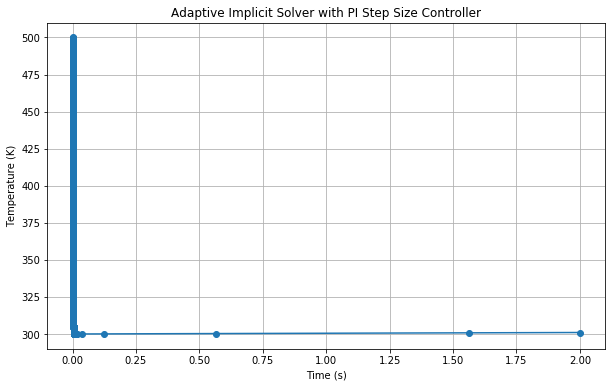

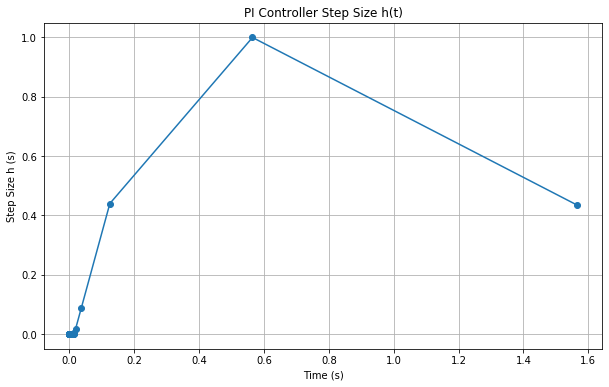

In [5]:
# Adaptive step size implicit solver using PI step size controller
def adaptive_solver_PI(T0, t0, tf, h0, tol=1e-4, h_min=1e-8, h_max=1.0):
    t_vals = [t0]
    T_vals = [T0]
    h_vals = []
    error_vals = []
    accept_reject = []

    t = t0
    T = T0
    h = h0

    accepted = 0
    rejected = 0
    total_iters = 0

    # Previous error for PI controller
    err_prev = tol

    # PI controller constants
    kP = 0.7
    kI = 0.4
    safety = 0.9

    while t < tf:
        if t + h > tf:
            h = tf - t

        # Estimate error using step doubling
        T_full, T_half, err, iters = estimate_error(T, t, h)
        total_iters += iters

        # Avoid division by zero
        if err < 1e-14:
            err = 1e-14

        # PI controller step size formula
        h_new = h * (tol / err)**kP * (err_prev / err)**kI
        h_new = safety * h_new

        # Limit h variability
        h_new = max(0.2 * h, min(5.0 * h, h_new))

        # Enforce min and max step size
        h_new = max(h_min, min(h_max, h_new))

        if err < tol:
            # Accept step and use more accurate two-half-step result
            t += h
            T = T_half

            t_vals.append(t)
            T_vals.append(T)
            h_vals.append(h)
            error_vals.append(err)
            accept_reject.append(1)

            accepted += 1
            err_prev = err
            h = h_new

        else:
            # Reject step and retry with smaller h
            rejected += 1
            accept_reject.append(0)
            h = h_new

    stats = {
        "accepted": accepted,
        "rejected": rejected,
        "total_iters": total_iters
    }

    return np.array(t_vals), np.array(T_vals), np.array(h_vals), np.array(error_vals), accept_reject, stats

# Run PI adaptive solver
t_PI, T_PI, h_PI, err_PI, ar_PI, stats_PI = adaptive_solver_PI(
    T0=500,
    t0=0,
    tf=2,
    h0=0.1,
    tol=1e-4
)

print("PI Controller Adaptive Solver")
print("-----------------------------")
print(f"Accepted steps: {stats_PI['accepted']}")
print(f"Rejected steps: {stats_PI['rejected']}")
print(f"Total Newton iterations: {stats_PI['total_iters']}")

# Plot PI adaptive solution
plt.figure(figsize=(10,6))
plt.plot(t_PI, T_PI, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Adaptive Implicit Solver with PI Step Size Controller")
plt.grid(True)
plt.show()

# Plot PI step size history
plt.figure(figsize=(10,6))
plt.plot(t_PI[:-1], h_PI, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Step Size h (s)")
plt.title("PI Controller Step Size h(t)")
plt.grid(True)
plt.show()

# Bonus 2: Embedded RK2 Method

Embedded RK2 Adaptive Solver
----------------------------
Accepted steps: 3348
Rejected steps: 8
Function evaluations: 6712


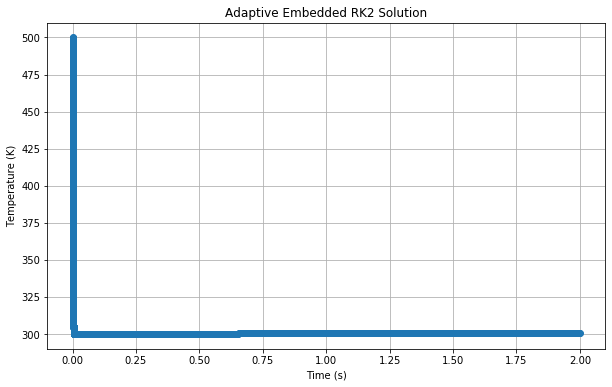

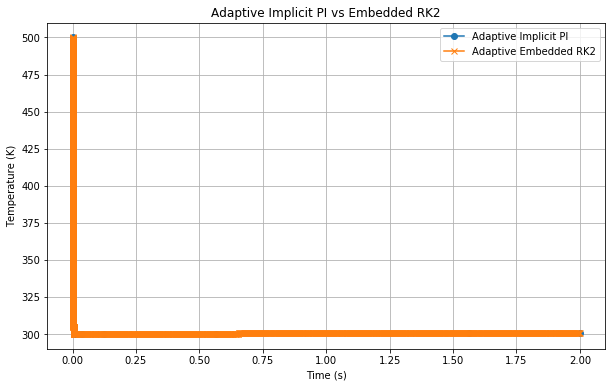

In [6]:
# Define the stiff cooling ODE
def f(t, T):
    return -1000*T + 1000*(300 + 50*np.sin(0.01*t))


# One embedded RK2 step
def embedded_RK2_step(T_n, t_n, h):
    # First slope
    k1 = f(t_n, T_n)

    # Second slope using Euler prediction
    T_euler = T_n + h * k1
    k2 = f(t_n + h, T_euler)

    # RK2 corrected value
    T_RK2 = T_n + (h / 2) * (k1 + k2)

    # Error estimate from embedded Euler/RK2 pair
    err = abs(T_RK2 - T_euler)

    return T_RK2, err

# Adaptive embedded RK2 solver
def adaptive_RK2_solver(T0, t0, tf, h0, tol=1e-4, h_min=1e-8, h_max=1.0):
    t_vals = [t0]
    T_vals = [T0]
    h_vals = []
    error_vals = []
    accept_reject = []

    t = t0
    T = T0
    h = h0

    accepted = 0
    rejected = 0
    function_evals = 0

    safety = 0.9

    while t < tf:
        if t + h > tf:
            h = tf - t

        T_new, err = embedded_RK2_step(T, t, h)
        function_evals += 2

        if err < 1e-14:
            err = 1e-14

        # RK2 is second-order, so use exponent 1/3 for local error control
        h_new = safety * h * (tol / err)**(1/3)

        # Limit step-size changes
        h_new = max(0.2 * h, min(5.0 * h, h_new))
        h_new = max(h_min, min(h_max, h_new))

        if err < tol:
            # Accept step
            t += h
            T = T_new

            t_vals.append(t)
            T_vals.append(T)
            h_vals.append(h)
            error_vals.append(err)
            accept_reject.append(1)

            accepted += 1
            h = h_new

        else:
            # Reject step
            rejected += 1
            accept_reject.append(0)
            h = h_new

    stats = {
        "accepted": accepted,
        "rejected": rejected,
        "function_evals": function_evals
    }

    return np.array(t_vals), np.array(T_vals), np.array(h_vals), np.array(error_vals), accept_reject, stats

# Run embedded RK2 adaptive solver
t_RK2, T_RK2, h_RK2, err_RK2, ar_RK2, stats_RK2 = adaptive_RK2_solver(
    T0=500,
    t0=0,
    tf=2,
    h0=0.0005,
    tol=1e-4
)

print("Embedded RK2 Adaptive Solver")
print("----------------------------")
print(f"Accepted steps: {stats_RK2['accepted']}")
print(f"Rejected steps: {stats_RK2['rejected']}")
print(f"Function evaluations: {stats_RK2['function_evals']}")

# Plot embedded RK2 solution
plt.figure(figsize=(10,6))
plt.plot(t_RK2, T_RK2, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Adaptive Embedded RK2 Solution")
plt.grid(True)
plt.show()

# Compare PI implicit solver and embedded RK2
plt.figure(figsize=(10,6))
plt.plot(t_PI, T_PI, marker='o', label="Adaptive Implicit PI")
plt.plot(t_RK2, T_RK2, marker='x', label="Adaptive Embedded RK2")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Adaptive Implicit PI vs Embedded RK2")
plt.legend()
plt.grid(True)
plt.show()